# Figure 8c — Responses and anomalies at 850 hPa

Three-row, two-column comparison: absolute responses (left) and each response minus `EXP_B` (right).

In [1]:
import os
import warnings

import cartopy.crs as ccrs
import cartopy.util as cutil
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import xarray as xr
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore', message='invalid value encountered in create_collection', category=RuntimeWarning)
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], 'axes.unicode_minus': False})

nc_path = '/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig7/combined_ncep_r2_moist_lbm.nc'
target_lev, time_idx = 850.0, 14
ds = xr.open_dataset(nc_path, decode_times=False)

experiments = {'A1': 'EXP_B', 'A2': 'EXP_B_S-1', 'A3': 'EXP_B_S-12', 'A4': 'EXP_B_S-123'}
data_abs = {}
for name, exp_id in experiments.items():
    field = ds.sel(experiment=exp_id, lev=target_lev).isel(time=time_idx)
    data_abs[name] = {'psi': field['psi'] / 1e6, 'u': field['u'], 'v': field['v']}

data_diff = {
    name: {key: data_abs[name][key] - data_abs['A1'][key] for key in ('psi', 'u', 'v')}
    for name in ('A2', 'A3', 'A4')
}
print(f'Loaded 850 hPa fields at time index {time_idx}; t = {ds.time.values[time_idx]}.')

Loaded 850 hPa fields at time index 14; t = 336.0.


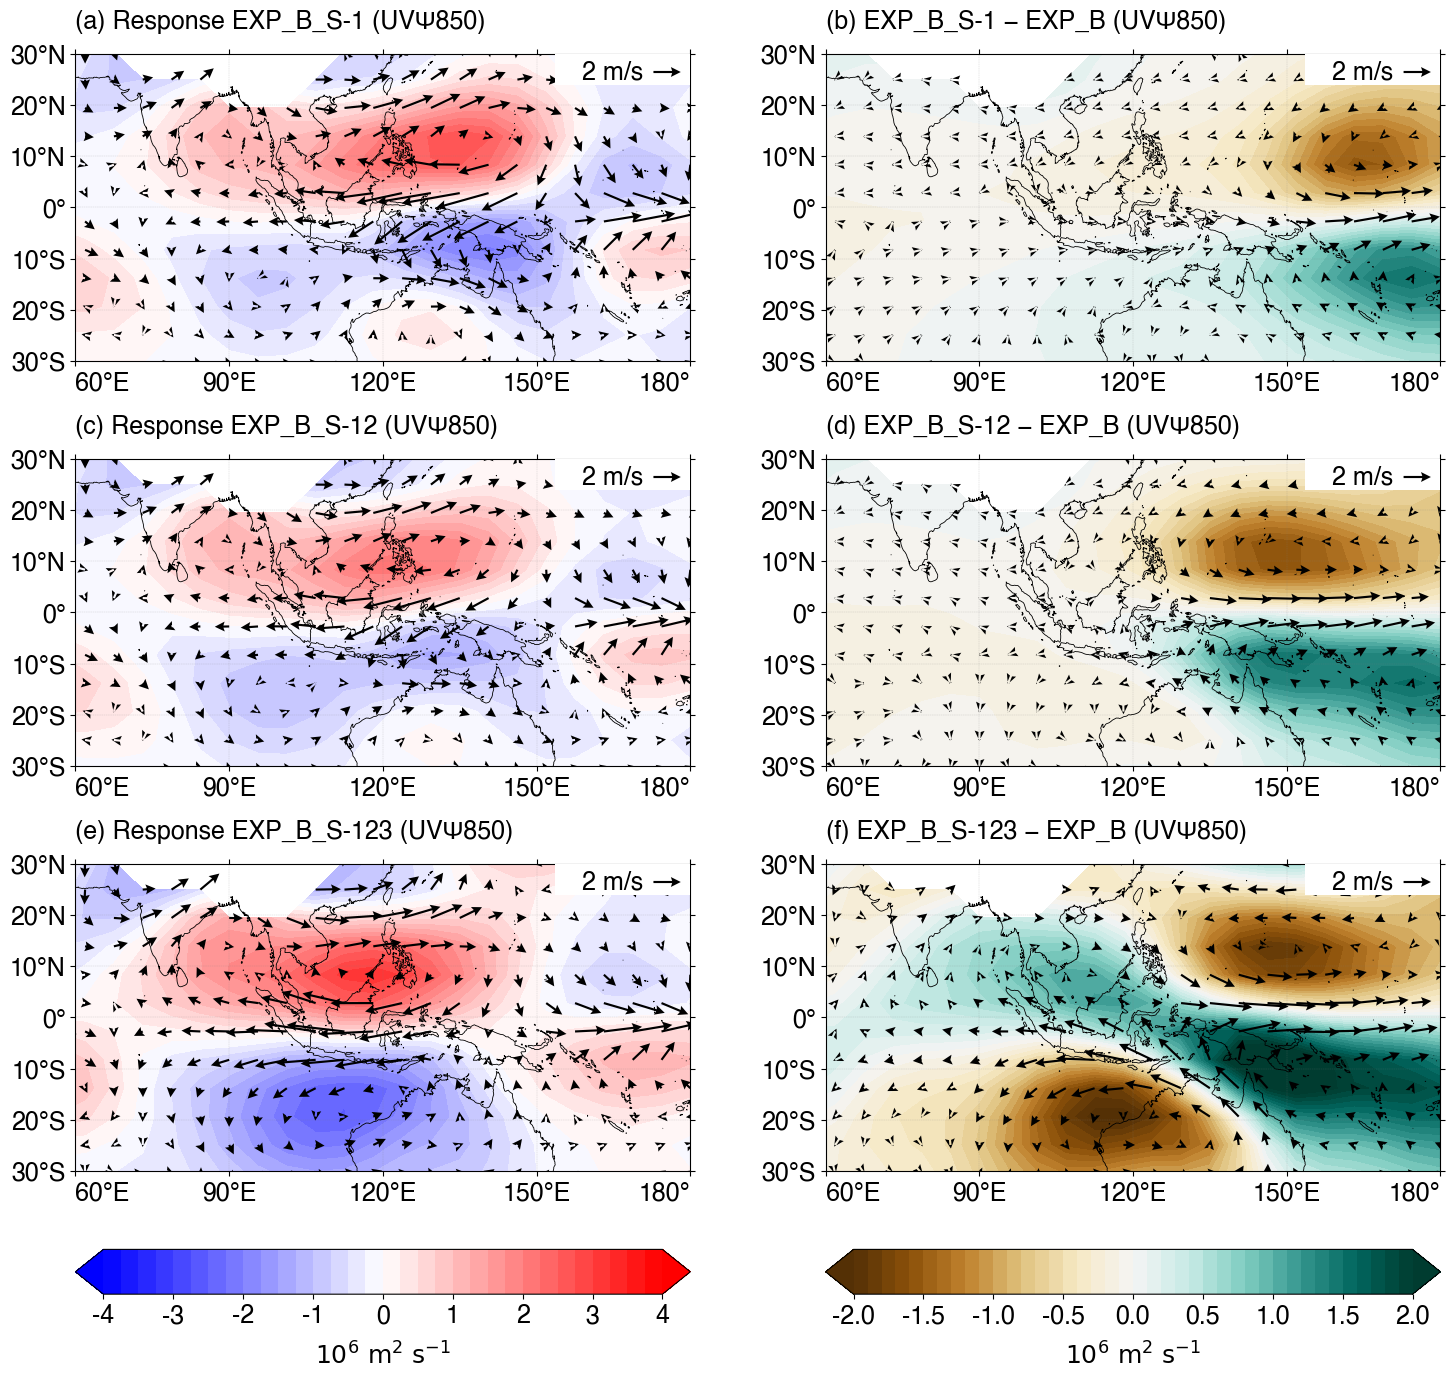

Saved plot to /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig7/fig8c.png


In [2]:
# Match the requested 3 × 2 layout: responses at left; EXP_B anomalies at right.
PLOT_FONTSIZE = 18
plt.rcParams.update({'font.size': PLOT_FONTSIZE, 'axes.titlesize': PLOT_FONTSIZE, 'xtick.labelsize': PLOT_FONTSIZE, 'ytick.labelsize': PLOT_FONTSIZE})
response_levels = np.arange(-4.0, 4.01, 0.25)
difference_levels = np.arange(-2.0, 2.01, 0.1)
response_cmap = 'bwr'
difference_cmap = 'BrBG'
response_norm = mcolors.Normalize(vmin=-4.0, vmax=4.0)
difference_norm = mcolors.Normalize(vmin=-2.0, vmax=2.0)

fig = plt.figure(figsize=(15, 14))
gs = fig.add_gridspec(3, 2, left=0.055, right=0.965, bottom=0.15, top=0.96, hspace=0.25, wspace=0.22)
axes = [[fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree(central_longitude=180)) for col in range(2)] for row in range(3)]

rows = [
    ('A2', '(a) Response EXP_B_S-1 (UVΨ850)', '(b) EXP_B_S-1 − EXP_B (UVΨ850)'),
    ('A3', '(c) Response EXP_B_S-12 (UVΨ850)', '(d) EXP_B_S-12 − EXP_B (UVΨ850)'),
    ('A4', '(e) Response EXP_B_S-123 (UVΨ850)', '(f) EXP_B_S-123 − EXP_B (UVΨ850)'),
]
xticks, yticks = [60, 90, 120, 150, 180], [-30, -20, -10, 0, 10, 20, 30]
lon2d, lat2d = np.meshgrid(ds.lon.values, ds.lat.values)

def draw_panel(ax, fields, title, levels, norm, cmap):
    psi_cyclic, lon_cyclic = cutil.add_cyclic_point(fields['psi'].values, coord=ds.lon.values)
    cf = ax.contourf(lon_cyclic, ds.lat.values, psi_cyclic, levels=levels, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), extend='both')
    ax.coastlines(resolution='50m', color='black', linewidth=0.6, zorder=3)
    ax.set_extent([60, 180, -30, 30], crs=ccrs.PlateCarree())
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
    ax.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
    ax.tick_params(direction='out', top=True, right=True, labelright=False, labelsize=PLOT_FONTSIZE)
    ax.gridlines(xlocs=xticks, ylocs=yticks, draw_labels=False, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
    q = ax.quiver(lon2d, lat2d, fields['u'].values, fields['v'].values, transform=ccrs.PlateCarree(), color='black', scale=45, width=0.0035, headwidth=4.6, headlength=4.6, headaxislength=4.0, minshaft=0, minlength=0, zorder=4)
    ax.add_patch(mpatches.Rectangle((0.78, 0.897), 0.22, 0.10, transform=ax.transAxes, facecolor='white', edgecolor='none', zorder=5))
    qk = ax.quiverkey(q, X=0.94, Y=0.94, U=2, label='2 m/s', labelpos='W', coordinates='axes', fontproperties={'size': PLOT_FONTSIZE}, labelsep=0.1)
    qk.set_zorder(6)
    ax.set_title(title, fontsize=PLOT_FONTSIZE, fontweight='bold', loc='left', pad=18)
    return cf

for row, (name, response_title, difference_title) in enumerate(rows):
    response_cf = draw_panel(axes[row][0], data_abs[name], response_title, response_levels, response_norm, response_cmap)
    difference_cf = draw_panel(axes[row][1], data_diff[name], difference_title, difference_levels, difference_norm, difference_cmap)

fig.canvas.draw()
for row_axes in axes:
    for ax in row_axes:
        for label in ax.get_xticklabels():
            if '60' in label.get_text(): label.set_ha('left')
            elif '180' in label.get_text(): label.set_ha('right')

# Colourbars below panels (e) and (f), using the Fig6a geometry and typography.
colorbar_height = 0.032
colorbar_labelpad = 10
streamfunction_cbar_label = r'$10^6\ \mathrm{m}^2\ \mathrm{s}^{-1}$'

def format_nice_number(value, pos=None):
    if not np.isfinite(value): return ''
    if np.isclose(value, 0.0): return '0'
    return f'{value:g}'

colorbar_specs = [
    (0, response_cf, np.arange(-4.0, 4.1, 1.0)),
    (1, difference_cf, np.arange(-2.0, 2.1, 0.5)),
]
for col, contour_set, ticks in colorbar_specs:
    pos = axes[-1][col].get_position()
    cbar_width = pos.width
    cbar_x0 = pos.x0 + (pos.width - cbar_width) / 2
    cbar_y0 = pos.y0 - 0.088
    cax = fig.add_axes([cbar_x0, cbar_y0, cbar_width, colorbar_height])
    cbar = fig.colorbar(contour_set, cax=cax, orientation='horizontal', extend='both', ticks=ticks)
    cbar.ax.xaxis.set_major_formatter(FuncFormatter(format_nice_number))
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=PLOT_FONTSIZE)
    cbar.set_label(streamfunction_cbar_label, fontsize=PLOT_FONTSIZE, labelpad=colorbar_labelpad)


output_dir = '/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig7'
os.makedirs(output_dir, exist_ok=True)
png_path = os.path.join(output_dir, 'fig8c.png')
fig.savefig(png_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved plot to {png_path}')